# YOLO-based Visual Concept Retrieval
## YOLO để truy xuất, Visual Genome để đánh giá

Notebook này triển khai hướng làm mới cho phần Visual Concept Retrieval:

```text
Ảnh trong subset 30K
    ↓
YOLO tự phát hiện object
    ↓
Tạo YOLO concept index
    ↓
Search ảnh bằng text query
    ↓
Dùng objects.json của Visual Genome làm ground truth để đánh giá Top-K
```

Điểm quan trọng:

- **YOLO index** là index dùng để truy xuất thật.
- **Visual Genome objects.json** chỉ dùng để đánh giá, không dùng để lập chỉ mục truy xuất.
- Notebook dùng chung `indexes/index_mapping_common.csv` của cả nhóm.

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import thư viện và cấu hình

In [ ]:
import os
import re
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

VG_DIR = "/content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome"
ANN_DIR = os.path.join(VG_DIR, "annotations")
INDEX_DIR = os.path.join(VG_DIR, "indexes")
COMMON_IMG_DIR = os.path.join(VG_DIR, "common_images")

OBJECTS_PATH = os.path.join(ANN_DIR, "objects.json")
COMMON_MAPPING_CSV = os.path.join(INDEX_DIR, "index_mapping_common.csv")

YOLO_INDEX_PATH = os.path.join(INDEX_DIR, "yolo_concept_index_30k.json")
YOLO_IDF_PATH = os.path.join(INDEX_DIR, "yolo_concept_idf_30k.json")
VG_GT_PATH = os.path.join(INDEX_DIR, "vg_ground_truth_index_30k.json")

print("VG_DIR:", VG_DIR)
print("COMMON_MAPPING_CSV:", COMMON_MAPPING_CSV)
print("OBJECTS_PATH:", OBJECTS_PATH)

VG_DIR: /content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome
COMMON_MAPPING_CSV: /content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome/indexes/index_mapping_common.csv
OBJECTS_PATH: /content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome/annotations/objects.json


## 3. Load mapping chung

Mapping chung cần có các cột:

```text
global_id, standard_filename, image_id, original_filename,
original_folder, original_relative_path, common_relative_path
```

In [ ]:
if not os.path.exists(COMMON_MAPPING_CSV):
    raise FileNotFoundError("Không tìm thấy index_mapping_common.csv. Hãy chạy notebook tạo mapping chung trước.")

mapping_df = pd.read_csv(COMMON_MAPPING_CSV, dtype={"image_id": str})

required_cols = [
    "global_id", "standard_filename", "image_id", "original_filename",
    "original_folder", "original_relative_path", "common_relative_path"
]
missing_cols = [c for c in required_cols if c not in mapping_df.columns]
if missing_cols:
    raise ValueError(f"Mapping thiếu cột: {missing_cols}")

mapping_by_image_id = {
    str(row["image_id"]): row.to_dict()
    for _, row in mapping_df.iterrows()
}

print("Loaded mapping rows:", len(mapping_df))
display(mapping_df.head())

Loaded mapping rows: 30000


,global_id,standard_filename,image_id,original_filename,original_folder,original_relative_path,common_relative_path,new_file,new_path,original_path
0,1,000001.jpg,2398397.0,2398397.jpg,VG_100K_2,images/VG_100K_2/2398397.jpg,common_images/000001.jpg,000001.jpg,/content/drive/MyDrive/IR_Photo_Gallery_Projec...,NaN
1,2,000002.jpg,2326031.0,2326031.jpg,VG_100K,images/VG_100K/2326031.jpg,common_images/000002.jpg,000002.jpg,/content/drive/MyDrive/IR_Photo_Gallery_Projec...,NaN
2,3,000003.jpg,1592987.0,1592987.jpg,VG_100K,images/VG_100K/1592987.jpg,common_images/000003.jpg,000003.jpg,/content/drive/MyDrive/IR_Photo_Gallery_Projec...,NaN
3,4,000004.jpg,2412396.0,2412396.jpg,VG_100K_2,images/VG_100K_2/2412396.jpg,common_images/000004.jpg,000004.jpg,/content/drive/MyDrive/IR_Photo_Gallery_Projec...,NaN
4,5,000005.jpg,2348473.0,2348473.jpg,VG_100K,images/VG_100K/2348473.jpg,common_images/000005.jpg,000005.jpg,/content/drive/MyDrive/IR_Photo_Gallery_Projec...,NaN


## 4. Kiểm tra ảnh trong mapping

Ưu tiên ảnh chuẩn trong `common_images/`. Nếu chưa có thì dùng ảnh gốc bằng `original_relative_path`.

In [ ]:
def resolve_image_path(row, prefer_common=True):
    if prefer_common and isinstance(row.get("common_relative_path"), str):
        p = os.path.join(VG_DIR, row["common_relative_path"])
        if os.path.exists(p):
            return p

    if isinstance(row.get("original_relative_path"), str):
        p = os.path.join(VG_DIR, row["original_relative_path"])
        if os.path.exists(p):
            return p

    return None

def verify_images(mapping_df, sample_size=None):
    df = mapping_df if sample_size is None else mapping_df.head(sample_size)
    missing = []
    existing = 0

    for _, row in df.iterrows():
        p = resolve_image_path(row.to_dict(), prefer_common=True)
        if p is None:
            missing.append(row["image_id"])
        else:
            existing += 1

    print("Checked:", len(df))
    print("Existing:", existing)
    print("Missing:", len(missing))
    if missing:
        print("First missing:", missing[:20])
    return missing

missing_images = verify_images(mapping_df)

Checked: 30000
Existing: 30000
Missing: 0


## 5. Cài đặt và load YOLO

In [ ]:
!pip -q install ultralytics

In [ ]:
from ultralytics import YOLO

YOLO_MODEL_NAME = "yolov8s.pt"  # có thể đổi thành yolov8s.pt nếu muốn chính xác hơn
yolo_model = YOLO(YOLO_MODEL_NAME)

print("Loaded YOLO model:", YOLO_MODEL_NAME)
print("Number of classes:", len(yolo_model.names))
print(yolo_model.names)

Loaded YOLO model: yolov8s.pt
Number of classes: 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 're

## 6. Chuẩn hóa label

YOLO dùng COCO labels. Visual Genome có vocabulary rộng hơn. Ta chuẩn hóa một số nhãn để đánh giá ổn định.

In [ ]:
LABEL_NORMALIZATION = {
    "cell phone": "phone",
    "mobile phone": "phone",
    "tv": "television",
    "couch": "sofa",
    "motorbike": "motorcycle",
    "bike": "bicycle",
    "aeroplane": "airplane",
    "dining table": "table",
    "potted plant": "plant",
    "sports ball": "ball",
    "tennis racket": "racket",
    "baseball bat": "bat",
    "baseball glove": "glove",
}

SYNONYM_MAP = {
    "man": "person",
    "woman": "person",
    "boy": "person",
    "girl": "person",
    "kid": "person",
    "child": "person",
    "children": "person",
    "bike": "bicycle",
    "motorbike": "motorcycle",
    "auto": "car",
    "automobile": "car",
    "sofa": "sofa",
    "couch": "sofa",
    "tv": "television",
    "cellphone": "phone",
    "mobile phone": "phone",
    "dining table": "table",
    "sports ball": "ball",
}

def normalize_text_label(label):
    label = str(label).lower().strip()
    label = re.sub(r"\s+", " ", label)
    label = re.sub(r"[^a-z0-9\s\-]", "", label).strip()
    return LABEL_NORMALIZATION.get(label, label)

YOLO_VOCAB = set(normalize_text_label(v) for v in yolo_model.names.values())
print("YOLO vocab size:", len(YOLO_VOCAB))
print(sorted(YOLO_VOCAB))

YOLO vocab size: 80
['airplane', 'apple', 'backpack', 'ball', 'banana', 'bat', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'chair', 'clock', 'cow', 'cup', 'dog', 'donut', 'elephant', 'fire hydrant', 'fork', 'frisbee', 'giraffe', 'glove', 'hair drier', 'handbag', 'horse', 'hot dog', 'keyboard', 'kite', 'knife', 'laptop', 'microwave', 'motorcycle', 'mouse', 'orange', 'oven', 'parking meter', 'person', 'phone', 'pizza', 'plant', 'racket', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sheep', 'sink', 'skateboard', 'skis', 'snowboard', 'sofa', 'spoon', 'stop sign', 'suitcase', 'surfboard', 'table', 'teddy bear', 'television', 'tie', 'toaster', 'toilet', 'toothbrush', 'traffic light', 'train', 'truck', 'umbrella', 'vase', 'wine glass', 'zebra']


## 7. Detect thử một ảnh bằng YOLO

In [ ]:
def yolo_detect_one_image(image_path, model=yolo_model, conf_threshold=0.25):
    results = model(image_path, conf=conf_threshold, verbose=False)
    concept_counter = Counter()
    detections = []

    for result in results:
        names = result.names
        if result.boxes is None:
            continue

        for box in result.boxes:
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            raw_label = names[cls_id]
            label = normalize_text_label(raw_label)
            concept_counter[label] += 1
            xyxy = box.xyxy[0].cpu().numpy().tolist()

            detections.append({
                "label": label,
                "raw_label": raw_label,
                "confidence": conf,
                "x1": float(xyxy[0]),
                "y1": float(xyxy[1]),
                "x2": float(xyxy[2]),
                "y2": float(xyxy[3]),
            })

    return {
        "concepts": sorted(concept_counter.keys()),
        "concept_counts": dict(concept_counter),
        "num_objects": int(sum(concept_counter.values())),
        "detections": detections,
    }

sample_row = mapping_df.iloc[0].to_dict()
sample_path = resolve_image_path(sample_row, prefer_common=True)
print("Sample image path:", sample_path)

sample_item = yolo_detect_one_image(sample_path, conf_threshold=0.25)
print("Detected concepts:", sample_item["concepts"])
print("Concept counts:", sample_item["concept_counts"])
print("Num detections:", len(sample_item["detections"]))

Sample image path: /content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome/common_images/000001.jpg
Detected concepts: ['bench', 'car', 'person', 'train']
Concept counts: {'train': 1, 'person': 4, 'car': 3, 'bench': 1}
Num detections: 9


## 8. Hiển thị bounding boxes YOLO

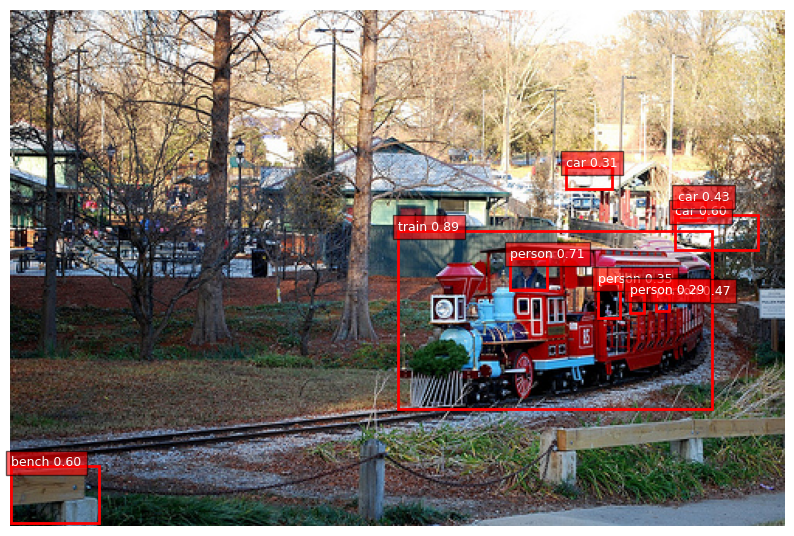

In [ ]:
import matplotlib.patches as patches

def show_yolo_detections(image_path, yolo_item, max_boxes=20):
    img = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.imshow(img)
    ax.axis("off")

    for det in yolo_item["detections"][:max_boxes]:
        x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1,
            f"{det['label']} {det['confidence']:.2f}",
            color="white", fontsize=9,
            bbox=dict(facecolor="red", alpha=0.6)
        )

    plt.show()

show_yolo_detections(sample_path, sample_item)

## 9. Tạo YOLO concept index

File sinh ra:

```text
indexes/yolo_concept_index_30k.json
```

Đây là index dùng để search thật.

- Test nhanh: `MAX_IMAGES_TO_INDEX = 500`
- Chạy full 30K: `MAX_IMAGES_TO_INDEX = None`
- Có resume: ảnh đã xử lý sẽ được bỏ qua.

In [ ]:
MAX_IMAGES_TO_INDEX = 3000
CONF_THRESHOLD = 0.25
SAVE_EVERY = 200

def load_existing_yolo_index():
    if os.path.exists(YOLO_INDEX_PATH):
        with open(YOLO_INDEX_PATH, "r", encoding="utf-8") as f:
            idx = json.load(f)
        print("Loaded existing YOLO index:", len(idx))
        return idx
    return {}

def save_yolo_index(index):
    with open(YOLO_INDEX_PATH, "w", encoding="utf-8") as f:
        json.dump(index, f, ensure_ascii=False, indent=2)

def build_yolo_index(mapping_df, max_images=None, conf_threshold=0.25, save_every=200):
    yolo_index = load_existing_yolo_index()
    df = mapping_df if max_images is None else mapping_df.head(max_images)

    processed_now = 0
    skipped = 0
    failed = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="YOLO indexing"):
        image_id = str(row["image_id"])
        if image_id in yolo_index:
            skipped += 1
            continue

        image_path = resolve_image_path(row.to_dict(), prefer_common=True)
        if image_path is None:
            failed.append((image_id, "missing image"))
            continue

        try:
            item = yolo_detect_one_image(image_path, model=yolo_model, conf_threshold=conf_threshold)
            yolo_index[image_id] = {
                "image_id": image_id,
                "global_id": int(row["global_id"]),
                "standard_filename": row["standard_filename"],
                "original_relative_path": row["original_relative_path"],
                "common_relative_path": row["common_relative_path"],
                "concepts": item["concepts"],
                "concept_counts": item["concept_counts"],
                "num_objects": item["num_objects"],
                "detections": item["detections"],
            }
            processed_now += 1

            if processed_now % save_every == 0:
                save_yolo_index(yolo_index)
                print("Checkpoint saved. Total indexed:", len(yolo_index))

        except Exception as e:
            failed.append((image_id, str(e)))

    save_yolo_index(yolo_index)
    print("Done.")
    print("Total indexed:", len(yolo_index))
    print("Processed now:", processed_now)
    print("Skipped:", skipped)
    print("Failed:", len(failed))
    if failed:
        print("First failed:", failed[:10])
    return yolo_index, failed

yolo_index, yolo_failed = build_yolo_index(
    mapping_df,
    max_images=MAX_IMAGES_TO_INDEX,
    conf_threshold=CONF_THRESHOLD,
    save_every=SAVE_EVERY,
)

Loaded existing YOLO index: 3000


YOLO indexing:   0%|          | 0/3000 [00:00<?, ?it/s]

Done.
Total indexed: 3000
Processed now: 0
Skipped: 3000
Failed: 0


## 10. Tính IDF cho YOLO concepts

In [ ]:
def build_yolo_idf(yolo_index, force_rebuild=True):
    if os.path.exists(YOLO_IDF_PATH) and not force_rebuild:
        with open(YOLO_IDF_PATH, "r", encoding="utf-8") as f:
            idf = json.load(f)
        print("Loaded YOLO IDF:", len(idf))
        return idf

    N = len(yolo_index)
    df = Counter()
    for item in yolo_index.values():
        for c in set(item["concepts"]):
            df[c] += 1

    idf = {c: math.log((N + 1) / (freq + 1)) + 1 for c, freq in df.items()}

    with open(YOLO_IDF_PATH, "w", encoding="utf-8") as f:
        json.dump(idf, f, ensure_ascii=False, indent=2)

    print("Saved:", YOLO_IDF_PATH)
    print("Vocab size:", len(idf))
    display(pd.Series(df).sort_values(ascending=False).to_frame("df"))
    return idf

yolo_idf = build_yolo_idf(yolo_index, force_rebuild=True)

Saved: /content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome/indexes/yolo_concept_idf_30k.json
Vocab size: 79


,df
person,1646
car,345
chair,291
table,258
cup,197
...,...
hot dog,20
scissors,18
parking meter,14
toothbrush,10


## 11. Tạo ground truth từ Visual Genome

File tạo ra:

```text
indexes/vg_ground_truth_index_30k.json
```

Ground truth này dùng để đánh giá, không dùng để search.

In [ ]:
def build_vg_ground_truth_index(mapping_df, vocab_for_eval, force_rebuild=False):
    if os.path.exists(VG_GT_PATH) and not force_rebuild:
        with open(VG_GT_PATH, "r", encoding="utf-8") as f:
            gt = json.load(f)
        print("Loaded GT index:", len(gt))
        return gt

    subset_ids = set(mapping_df["image_id"].astype(str).tolist())

    with open(OBJECTS_PATH, "r", encoding="utf-8") as f:
        objects_data = json.load(f)

    gt = {}

    for item in tqdm(objects_data, desc="Building VG ground truth"):
        image_id = str(item["image_id"])
        if image_id not in subset_ids:
            continue

        gt_concepts = []
        raw_concepts = []

        for obj in item.get("objects", []):
            for name in obj.get("names", []):
                raw = str(name).lower().strip()
                norm = normalize_text_label(raw)
                raw_concepts.append(raw)
                if norm in vocab_for_eval:
                    gt_concepts.append(norm)

        gt[image_id] = {
            "image_id": image_id,
            "gt_concepts": sorted(set(gt_concepts)),
            "raw_concepts": sorted(set(raw_concepts))[:200],
        }

    with open(VG_GT_PATH, "w", encoding="utf-8") as f:
        json.dump(gt, f, ensure_ascii=False, indent=2)

    print("Saved:", VG_GT_PATH)
    print("GT size:", len(gt))
    return gt

vocab_for_eval = set(yolo_idf.keys()).union(YOLO_VOCAB)
vg_gt_index = build_vg_ground_truth_index(mapping_df, vocab_for_eval, force_rebuild=False)

for k in list(vg_gt_index.keys())[:3]:
    print(k, "->", vg_gt_index[k]["gt_concepts"][:30])

Loaded GT index: 30000
2 -> ['backpack', 'bicycle', 'car']
6 -> ['apple', 'bottle', 'bowl', 'chair', 'fork', 'table']
7 -> ['book', 'chair', 'keyboard', 'laptop', 'mouse']


## 12. Xử lý query tiếng Việt và tiếng Anh bằng Semantic Query-to-Concept Mapping

Vấn đề thực tế:

```text
"người và con ngựa" -> dịch thành "people and horses"
```

Trong khi YOLO dùng class:

```text
person, horse
```

Nếu chỉ exact match thì sẽ không tìm được concept.

Notebook này dùng 3 tầng xử lý:

1. Exact match với YOLO vocabulary.
2. Rule/synonym/plural normalization, ví dụ `people -> person`, `horses -> horse`.
3. Text embedding fallback để map phrase gần nghĩa về YOLO class gần nhất.

Bước embedding chỉ dùng để **chuẩn hóa query về YOLO concepts**, không phải dùng để truy xuất ảnh kiểu CLIP.

In [ ]:
!pip -q install deep-translator sentence-transformers

In [ ]:
try:
    from deep_translator import GoogleTranslator
    TRANSLATOR_AVAILABLE = True
except Exception as e:
    print("Translator not available:", e)
    TRANSLATOR_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    TEXT_EMBEDDING_AVAILABLE = True
except Exception as e:
    print("SentenceTransformer not available:", e)
    TEXT_EMBEDDING_AVAILABLE = False


# =========================
# 1. Translation
# =========================

def translate_vi_to_en(query):
    if not TRANSLATOR_AVAILABLE:
        return query

    try:
        return GoogleTranslator(source="vi", target="en").translate(query)
    except Exception as e:
        print("Translation failed:", e)
        return query


def detect_language_auto(query):
    vietnamese_chars = "ăâđêôơưáàảãạắằẳẵặấầẩẫậéèẻẽẹếềểễệíìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữựýỳỷỹỵ"
    return "vi" if any(ch in query.lower() for ch in vietnamese_chars) else "en"


# =========================
# 2. Query normalization
# =========================

SYNONYM_MAP.update({
    # people/person
    "people": "person",
    "persons": "person",
    "men": "person",
    "women": "person",
    "boys": "person",
    "girls": "person",
    "kids": "person",
    "children": "person",

    # common plurals
    "horses": "horse",
    "dogs": "dog",
    "cats": "cat",
    "cars": "car",
    "buses": "bus",
    "trucks": "truck",
    "bicycles": "bicycle",
    "motorcycles": "motorcycle",
    "chairs": "chair",
    "tables": "table",
    "bottles": "bottle",
    "cups": "cup",
    "umbrellas": "umbrella",
    "birds": "bird",
    "cows": "cow",
    "elephants": "elephant",
    "zebras": "zebra",
    "giraffes": "giraffe",
    "balls": "ball",
    "phones": "phone",
    "televisions": "television",
    "sofas": "sofa",

    # semantic variants
    "automobile": "car",
    "automobiles": "car",
    "vehicle": "car",
    "vehicles": "car",
    "bike": "bicycle",
    "bikes": "bicycle",
    "motorbike": "motorcycle",
    "motorbikes": "motorcycle",
    "cellphone": "phone",
    "cellphones": "phone",
    "mobile": "phone",
    "mobile phone": "phone",
    "mobile phones": "phone",
})

STOPWORDS = {
    "a", "an", "the", "and", "or", "of", "with", "on", "in", "at", "near",
    "to", "from", "by", "for", "is", "are", "was", "were", "be", "being"
}

def extract_ngrams(tokens, max_ngram=3):
    phrases = []
    for n in range(max_ngram, 0, -1):
        for i in range(len(tokens) - n + 1):
            phrases.append(" ".join(tokens[i:i+n]))
    return phrases


def normalize_plural_candidate(text, vocab):
    if text in vocab:
        return text

    if text.endswith("ies"):
        candidate = text[:-3] + "y"
        if candidate in vocab:
            return candidate

    if text.endswith("es"):
        candidate = text[:-2]
        if candidate in vocab:
            return candidate

    if text.endswith("s") and len(text) > 3:
        candidate = text[:-1]
        if candidate in vocab:
            return candidate

    return text


def normalize_query_token_or_phrase(text, vocab):
    text = normalize_text_label(text)
    text = SYNONYM_MAP.get(text, text)
    text = normalize_plural_candidate(text, vocab)
    return text


# =========================
# 3. Text embedding fallback
# =========================

USE_TEXT_EMBEDDING = True
TEXT_EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TEXT_EMBED_THRESHOLD = 0.55

text_embedder = None
embedding_vocab_cache = {}

def get_text_embedder():
    global text_embedder

    if not USE_TEXT_EMBEDDING or not TEXT_EMBEDDING_AVAILABLE:
        return None

    if text_embedder is None:
        text_embedder = SentenceTransformer(TEXT_EMBED_MODEL_NAME)
        print("Loaded text embedding model:", TEXT_EMBED_MODEL_NAME)

    return text_embedder


def get_vocab_embeddings(vocab):
    vocab_list = sorted(list(vocab))
    cache_key = tuple(vocab_list)

    if cache_key in embedding_vocab_cache:
        return embedding_vocab_cache[cache_key]

    model = get_text_embedder()

    if model is None:
        return vocab_list, None

    embeddings = model.encode(
        vocab_list,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    embedding_vocab_cache[cache_key] = (vocab_list, embeddings)
    return vocab_list, embeddings


def should_try_embedding(phrase):
    tokens = phrase.split()

    if not tokens:
        return False

    if len(tokens) == 1 and tokens[0] in STOPWORDS:
        return False

    # Tránh map các cụm có stopword như "people and horses".
    # Unigram "people", "horses" đã được xử lý bằng rule.
    if len(tokens) > 1 and any(t in STOPWORDS for t in tokens):
        return False

    return True


def map_phrase_to_vocab_by_embedding(phrase, vocab, threshold=TEXT_EMBED_THRESHOLD):
    vocab_list, vocab_embeddings = get_vocab_embeddings(vocab)

    if vocab_embeddings is None:
        return None, 0.0

    model = get_text_embedder()
    phrase_embedding = model.encode(
        [phrase],
        normalize_embeddings=True
    )[0]

    sims = np.dot(vocab_embeddings, phrase_embedding)
    best_idx = int(np.argmax(sims))
    best_label = vocab_list[best_idx]
    best_score = float(sims[best_idx])

    if best_score >= threshold:
        return best_label, best_score

    return None, best_score


def extract_query_concepts(query_en, vocab, max_ngram=3, use_embedding=True):
    query = query_en.lower()
    query = re.sub(r"[^a-z0-9\s\-]", " ", query)
    query = re.sub(r"\s+", " ", query).strip()

    tokens = query.split()
    candidates = extract_ngrams(tokens, max_ngram=max_ngram)

    concepts = []
    debug_matches = []

    for phrase in candidates:
        normalized = normalize_query_token_or_phrase(phrase, vocab)

        # 1. Exact / synonym / plural match
        if normalized in vocab:
            concepts.append(normalized)
            debug_matches.append({
                "phrase": phrase,
                "matched": normalized,
                "type": "exact_or_rule",
                "score": 1.0
            })
            continue

        # 2. Embedding fallback
        if use_embedding and should_try_embedding(phrase):
            mapped_label, sim_score = map_phrase_to_vocab_by_embedding(
                phrase=phrase,
                vocab=vocab,
                threshold=TEXT_EMBED_THRESHOLD
            )

            if mapped_label is not None and mapped_label in vocab:
                concepts.append(mapped_label)
                debug_matches.append({
                    "phrase": phrase,
                    "matched": mapped_label,
                    "type": "embedding",
                    "score": sim_score
                })

    concepts = sorted(list(set(concepts)))
    return concepts, debug_matches


def preprocess_query(query, vocab, language="auto", use_embedding=True):
    if language == "auto":
        language = detect_language_auto(query)

    query_en = translate_vi_to_en(query) if language == "vi" else query

    concepts, debug_matches = extract_query_concepts(
        query_en,
        vocab,
        max_ngram=3,
        use_embedding=use_embedding
    )

    return {
        "query_original": query,
        "language": language,
        "query_en": query_en,
        "query_concepts": concepts,
        "debug_matches": debug_matches
    }


# Vocab dùng cho query understanding: lấy từ YOLO index và thêm YOLO class vocabulary gốc.
YOLO_SEARCH_VOCAB = set(yolo_idf.keys()).union(YOLO_VOCAB)


test_queries = [
    "person horse",
    "people and horses",
    "người và con ngựa",
    "con chó và quả bóng",
    "cars and buses",
    "automobile near people",
]

for q in test_queries:
    info = preprocess_query(q, YOLO_SEARCH_VOCAB, language="auto", use_embedding=True)
    print("Original:", info["query_original"])
    print("English:", info["query_en"])
    print("Concepts:", info["query_concepts"])
    print("Debug:", info["debug_matches"][:5])
    print("-" * 80)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded text embedding model: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Original: person horse
English: person horse
Concepts: ['horse', 'person']
Debug: [{'phrase': 'person horse', 'matched': 'horse', 'type': 'embedding', 'score': 0.8653028011322021}, {'phrase': 'person', 'matched': 'person', 'type': 'exact_or_rule', 'score': 1.0}, {'phrase': 'horse', 'matched': 'horse', 'type': 'exact_or_rule', 'score': 1.0}]
--------------------------------------------------------------------------------
Original: people and horses
English: people and horses
Concepts: ['horse', 'person']
Debug: [{'phrase': 'people', 'matched': 'person', 'type': 'exact_or_rule', 'score': 1.0}, {'phrase': 'horses', 'matched': 'horse', 'type': 'exact_or_rule', 'score': 1.0}]
--------------------------------------------------------------------------------
Original: người và con ngựa
English: people and horses
Concepts: ['horse', 'person']
Debug: [{'phrase': 'people', 'matched': 'person', 'type': 'exact_or_rule', 'score': 1.0}, {'phrase': 'horses', 'matched': 'horse', 'type': 'exact_or_rule'

## 13. Search trên YOLO index

In [ ]:
def score_yolo_weighted(query_concepts, item, concept_idf, coverage_weight=0.35):
    counts = item["concept_counts"]
    matched = set(query_concepts).intersection(counts.keys())

    if not matched:
        return 0.0, []

    score = 0.0

    for c in matched:
        tf = counts.get(c, 0)
        score += (1.0 + math.log(tf)) * concept_idf.get(c, 1.0)

    coverage = len(matched) / max(len(query_concepts), 1)
    score *= (1.0 + coverage_weight * coverage)

    return float(score), sorted(matched)


def search_yolo_visual_concept(
    query,
    yolo_index,
    concept_idf,
    top_k=10,
    language="auto",
    use_embedding=True
):
    # Dùng union với YOLO_VOCAB để query vẫn map được các class YOLO
    # ngay cả khi chạy thử index nhỏ chưa có đủ class.
    search_vocab = set(concept_idf.keys()).union(YOLO_VOCAB)

    info = preprocess_query(
        query,
        search_vocab,
        language=language,
        use_embedding=use_embedding
    )

    concepts = info["query_concepts"]

    if not concepts:
        return {
            **info,
            "method": "YOLO-based Visual Concept Retrieval",
            "results": [],
            "warning": "No query concepts found."
        }

    results = []

    for image_id, item in yolo_index.items():
        score, matched = score_yolo_weighted(concepts, item, concept_idf)

        if score <= 0:
            continue

        results.append({
            "image_id": str(image_id),
            "global_id": item.get("global_id"),
            "standard_filename": item.get("standard_filename"),
            "score": float(score),
            "matched": matched,
            "num_matched": len(matched),
            "common_relative_path": item.get("common_relative_path"),
            "original_relative_path": item.get("original_relative_path"),
            "method": "YOLO-based Visual Concept Retrieval",
            "explanation": "Matched YOLO concepts: " + ", ".join(matched),
        })

    results = sorted(
        results,
        key=lambda r: (r["score"], r["num_matched"]),
        reverse=True
    )

    return {
        **info,
        "method": "YOLO-based Visual Concept Retrieval",
        "results": results[:top_k]
    }


output = search_yolo_visual_concept(
    "người và con ngựa",
    yolo_index,
    yolo_idf,
    top_k=10,
    language="vi",
    use_embedding=True
)

print("Original:", output["query_original"])
print("English:", output["query_en"])
print("Query concepts:", output["query_concepts"])
print("Debug matches:", output.get("debug_matches", [])[:10])
print()

if output.get("warning"):
    print("Warning:", output["warning"])

for i, r in enumerate(output["results"], 1):
    print(i, r["image_id"], r["standard_filename"], round(r["score"], 3), r["matched"])

Original: người và con ngựa
English: people and horses
Query concepts: ['horse', 'person']
Debug matches: [{'phrase': 'people', 'matched': 'person', 'type': 'exact_or_rule', 'score': 1.0}, {'phrase': 'horses', 'matched': 'horse', 'type': 'exact_or_rule', 'score': 1.0}]

1 2352177.0 002651.jpg 27.806 ['horse', 'person']
2 2417548.0 002361.jpg 25.532 ['horse', 'person']
3 2318854.0 000271.jpg 22.379 ['horse', 'person']
4 2331949.0 000521.jpg 21.286 ['horse', 'person']
5 2397552.0 001856.jpg 21.286 ['horse', 'person']
6 2387706.0 000025.jpg 20.804 ['horse', 'person']
7 2408537.0 002520.jpg 19.925 ['horse', 'person']
8 2336369.0 002407.jpg 19.465 ['horse', 'person']
9 2399998.0 002638.jpg 18.844 ['horse', 'person']
10 2402150.0 000620.jpg 18.557 ['horse', 'person']


## 14. Hiển thị kết quả search

Original: người và con ngựa
English: people and horses
Concepts: ['horse', 'person']
Method: YOLO-based Visual Concept Retrieval
Debug matches:
{'phrase': 'people', 'matched': 'person', 'type': 'exact_or_rule', 'score': 1.0}
{'phrase': 'horses', 'matched': 'horse', 'type': 'exact_or_rule', 'score': 1.0}


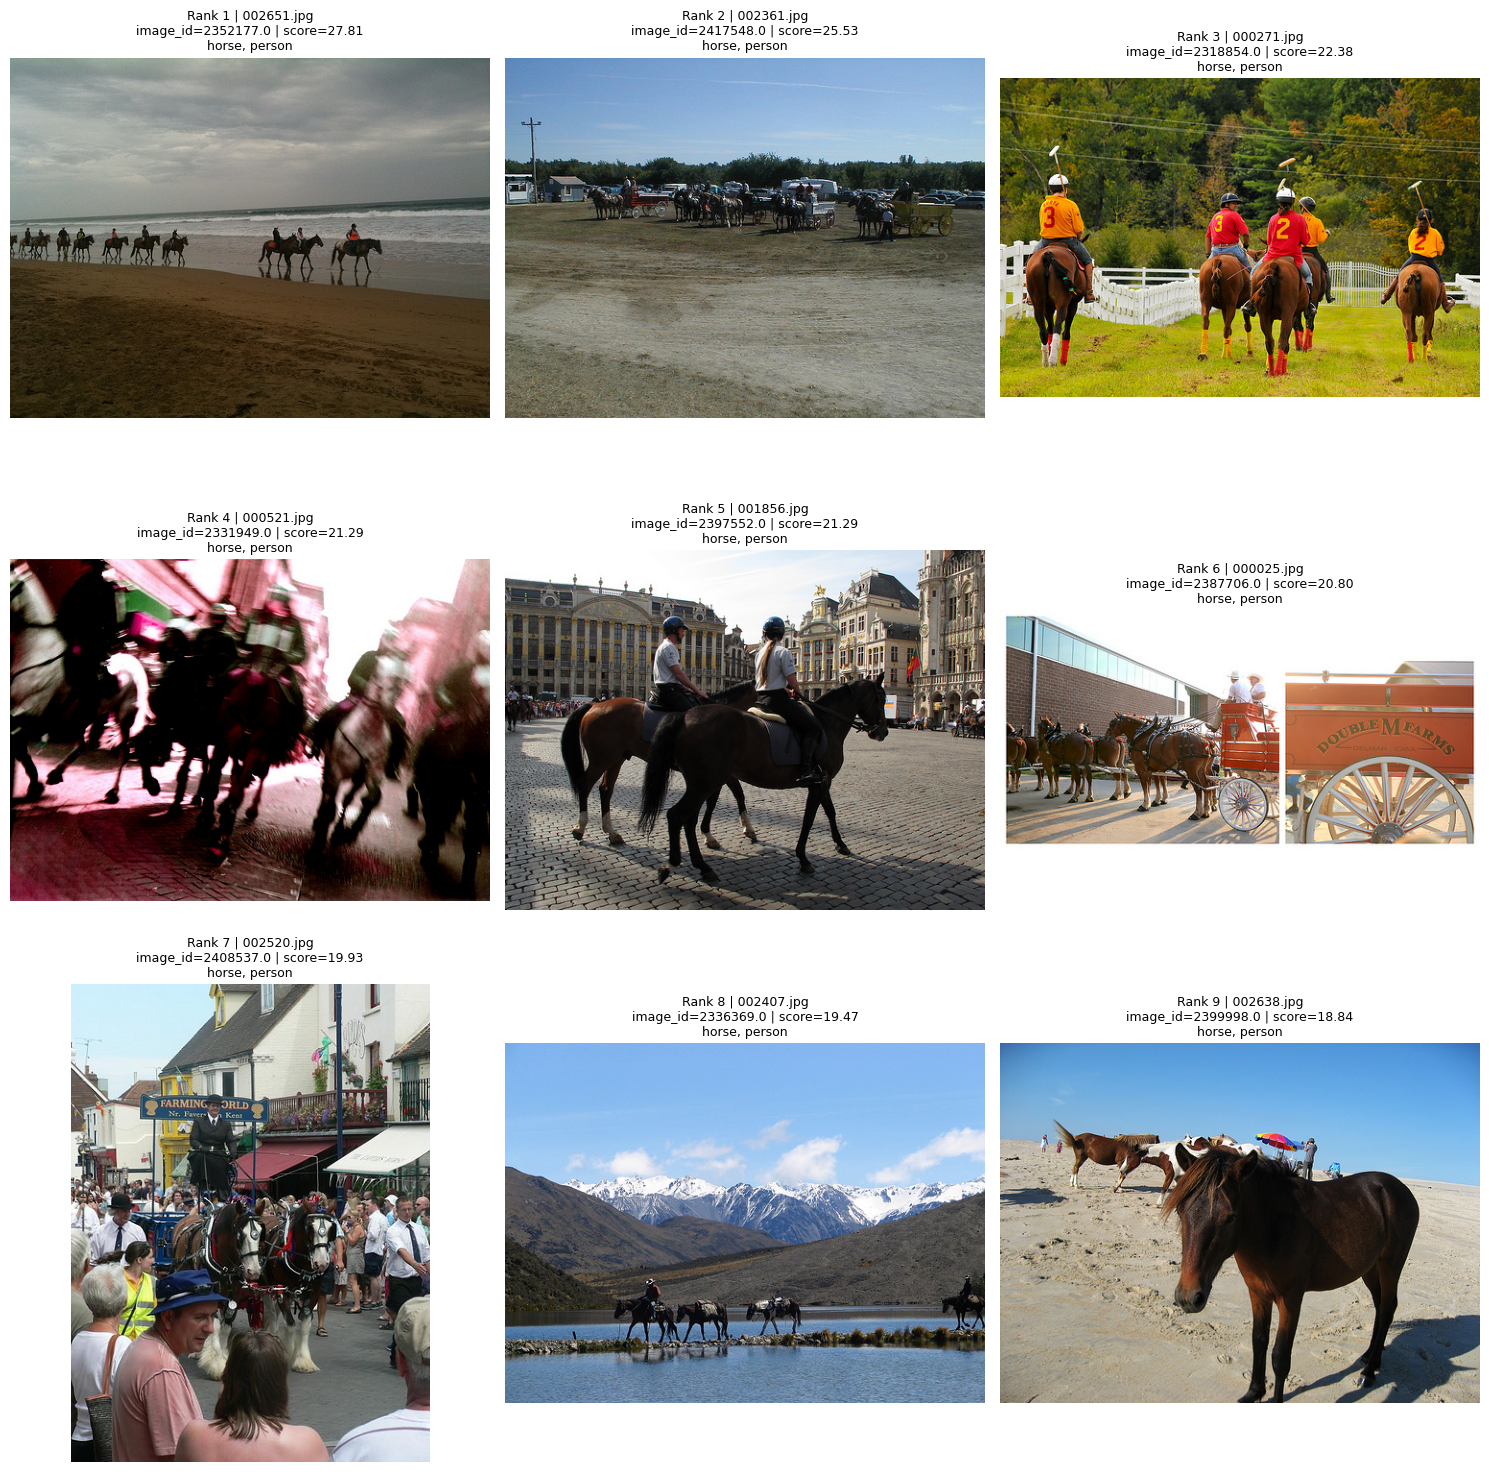

In [ ]:
def result_image_path(result, prefer_common=True):
    if prefer_common and result.get("common_relative_path"):
        p = os.path.join(VG_DIR, result["common_relative_path"])
        if os.path.exists(p):
            return p

    if result.get("original_relative_path"):
        p = os.path.join(VG_DIR, result["original_relative_path"])
        if os.path.exists(p):
            return p

    row = mapping_by_image_id.get(str(result["image_id"]))
    if row:
        return resolve_image_path(row, prefer_common=prefer_common)

    return None


def show_search_results(output, max_images=9, cols=3, prefer_common=True):
    results = output["results"][:max_images]

    print("Original:", output["query_original"])
    print("English:", output["query_en"])
    print("Concepts:", output["query_concepts"])
    print("Method:", output["method"])

    if output.get("debug_matches"):
        print("Debug matches:")
        for m in output["debug_matches"][:10]:
            print(m)

    if output.get("warning"):
        print("Warning:", output["warning"])

    if not results:
        print("No results.")
        return

    rows = math.ceil(len(results) / cols)
    plt.figure(figsize=(15, 5 * rows))

    for i, r in enumerate(results, 1):
        ax = plt.subplot(rows, cols, i)
        p = result_image_path(r, prefer_common=prefer_common)

        if p is None:
            ax.text(
                0.5,
                0.5,
                f"Missing image\n{r['image_id']}",
                ha="center",
                va="center"
            )
            ax.axis("off")
            continue

        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

        matched_text = ", ".join(r.get("matched", [])[:5])

        title = (
            f"Rank {i} | {r.get('standard_filename')}\n"
            f"image_id={r['image_id']} | score={r['score']:.2f}\n"
            f"{matched_text}"
        )

        ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


output = search_yolo_visual_concept(
    "người và con ngựa",
    yolo_index,
    yolo_idf,
    top_k=9,
    language="vi",
    use_embedding=True
)

show_search_results(output, max_images=9)

In [ ]:
import os
import json

VG_DIR = "/content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome"
INDEX_DIR = os.path.join(VG_DIR, "indexes")

VG_GT_PATH = os.path.join(INDEX_DIR, "vg_ground_truth_index_30k.json")
YOLO_INDEX_PATH = os.path.join(INDEX_DIR, "yolo_concept_index_30k.json")

def norm_image_id(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

with open(VG_GT_PATH, "r", encoding="utf-8") as f:
    vg_gt_index = json.load(f)

with open(YOLO_INDEX_PATH, "r", encoding="utf-8") as f:
    yolo_index = json.load(f)

# Chuẩn hóa key để tránh lệch 2318854 và 2318854.0
vg_gt_index = {
    norm_image_id(k): v
    for k, v in vg_gt_index.items()
}

yolo_index = {
    norm_image_id(k): v
    for k, v in yolo_index.items()
}

print("Loaded GT images:", len(vg_gt_index))
print("Loaded YOLO images:", len(yolo_index))
print("Overlap:", len(set(vg_gt_index.keys()) & set(yolo_index.keys())))

# Test nhanh
qset = {"person", "horse"}
relevant = []

for image_id in yolo_index.keys():
    gt_item = vg_gt_index.get(image_id, {})
    gt_concepts = set(gt_item.get("gt_concepts", []))

    if qset.issubset(gt_concepts):
        relevant.append(image_id)

print("Relevant for person horse:", len(relevant))
print("First relevant:", relevant[:10])

Loaded GT images: 30000
Loaded YOLO images: 3000
Overlap: 3000
Relevant for person horse: 27
First relevant: ['2387706', '2318854', '2373131', '2357776', '2331949', '498278', '2402150', '2406313', '2337945', '2349103']


## 15. Đánh giá Top-K bằng Visual Genome ground truth

Một ảnh được coi là relevant nếu ground truth của Visual Genome chứa toàn bộ query concepts.

In [ ]:
def get_relevant_images_for_query(query_concepts, vg_gt_index, candidate_image_ids=None):

    query_set = set(query_concepts)

    if not query_set:
        return set()

    if candidate_image_ids is not None:
        candidate_image_ids = {norm_image_id(x) for x in candidate_image_ids}
    else:
        candidate_image_ids = set(vg_gt_index.keys())

    relevant_set = set()

    for image_id in candidate_image_ids:
        image_id = norm_image_id(image_id)

        gt_item = vg_gt_index.get(image_id, {})
        gt_concepts = set(gt_item.get("gt_concepts", []))

        if query_set.issubset(gt_concepts):
            relevant_set.add(image_id)

    return relevant_set


def precision_at_k(results, relevant, k):
    top = results[:k]

    if not top:
        return 0.0

    return sum(1 for r in top if str(r["image_id"]) in relevant) / k


def recall_at_k(results, relevant, k):
    if not relevant:
        return 0.0

    top = results[:k]
    return sum(1 for r in top if str(r["image_id"]) in relevant) / len(relevant)


def average_precision_at_k(results, relevant, k):
    if not relevant:
        return 0.0

    hits = 0
    score = 0.0

    for i, r in enumerate(results[:k], 1):
        if str(r["image_id"]) in relevant:
            hits += 1
            score += hits / i

    return score / min(len(relevant), k)


def evaluate_query(query, language="en", k_values=(1, 5, 10), use_embedding=True):
    output = search_yolo_visual_concept(
        query,
        yolo_index,
        yolo_idf,
        top_k=max(k_values),
        language=language,
        use_embedding=use_embedding
    )

    relevant = get_relevant_images(
        output["query_concepts"],
        vg_gt_index,
        candidate_ids=set(yolo_index.keys())
    )

    row = {
        "query": query,
        "query_en": output["query_en"],
        "query_concepts": ", ".join(output["query_concepts"]),
        "num_relevant": len(relevant),
        "num_results": len(output["results"]),
    }

    for k in k_values:
        row[f"P@{k}"] = precision_at_k(output["results"], relevant, k)
        row[f"R@{k}"] = recall_at_k(output["results"], relevant, k)

    row[f"AP@{max(k_values)}"] = average_precision_at_k(
        output["results"],
        relevant,
        max(k_values)
    )

    return row, output, relevant


row, output_eval, relevant_set = evaluate_query(
    "person horse",
    language="en",
    use_embedding=True
)

print(row)
print("Relevant:", len(relevant_set))

{'query': 'person horse', 'query_en': 'person horse', 'query_concepts': 'horse, person', 'num_relevant': 27, 'num_results': 10, 'P@1': 0.0, 'R@1': 0.0, 'P@5': 0.6, 'R@5': 0.1111111111111111, 'P@10': 0.6, 'R@10': 0.2222222222222222, 'AP@10': 0.3738888888888888}
Relevant: 27


## 16. Đánh giá nhiều query

,query,query_en,query_concepts,num_relevant,num_results,P@1,R@1,P@5,R@5,P@10,R@10,AP@10
0,person horse,person horse,"horse, person",27,10,0.0,0.000000,0.6,0.111111,0.6,0.222222,0.373889
1,person bicycle,person bicycle,"bicycle, person",53,10,1.0,0.018868,0.2,0.018868,0.5,0.094340,0.276190
2,person umbrella,person umbrella,"person, umbrella",41,10,1.0,0.024390,0.8,0.097561,0.8,0.195122,0.706825
3,dog ball,dog ball,"ball, dog",2,10,0.0,0.000000,0.2,0.500000,0.1,0.500000,0.125000
4,cat sofa,cat sofa,"cat, sofa",12,10,0.0,0.000000,0.6,0.250000,0.5,0.416667,0.271111
5,car bus,car bus,"bus, car",40,10,0.0,0.000000,0.6,0.075000,0.6,0.150000,0.348095
6,car truck,car truck,"car, truck",39,10,1.0,0.025641,0.4,0.051282,0.4,0.102564,0.261111
7,table chair,table chair,"chair, table",107,10,1.0,0.009346,0.6,0.028037,0.6,0.056075,0.472698
8,bird tree,bird tree,"bird, plant",4,10,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
9,cow sheep,cow sheep,"cow, sheep",2,10,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000


,mean_score
P@1,0.533333
P@5,0.520000
P@10,0.513333
R@1,0.013689
R@5,0.107862
R@10,0.172817
AP@10,0.413193


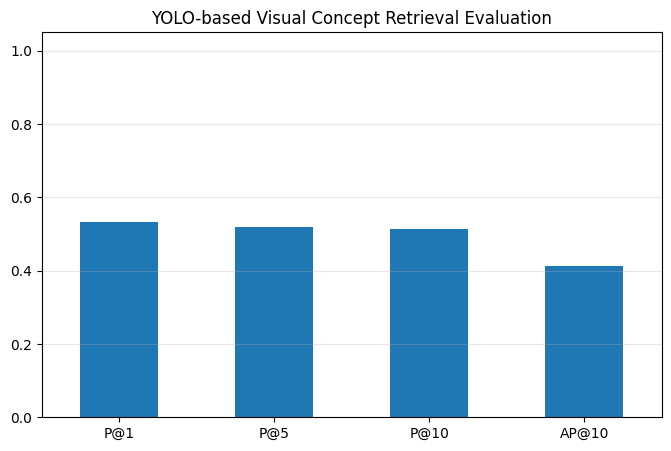

In [ ]:
evaluation_queries = [
    "person horse",
    "person bicycle",
    "person umbrella",
    "dog ball",
    "cat sofa",
    "car bus",
    "car truck",
    "table chair",
    "bird tree",
    "cow sheep",
    "elephant",
    "zebra",
    "giraffe",
    "bottle cup",
    "traffic light car",
]

rows = []
for q in evaluation_queries:
    row, _, _ = evaluate_query(q, language="en", k_values=(1,5,10))
    rows.append(row)

eval_df = pd.DataFrame(rows)
display(eval_df)

summary = eval_df[["P@1", "P@5", "P@10", "R@1", "R@5", "R@10", "AP@10"]].mean().to_frame("mean_score")
display(summary)

summary.loc[["P@1", "P@5", "P@10", "AP@10"]].plot(kind="bar", legend=False, figsize=(8,5))
plt.title("YOLO-based Visual Concept Retrieval Evaluation")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## 17. Demo thực chiến: thêm ảnh mới bằng YOLO

Cell này dùng khi app cho người dùng thêm ảnh tự chụp. Ảnh mới không có annotation, nên YOLO sẽ tự sinh concepts.

In [ ]:
def add_new_image_to_yolo_index(image_path, custom_image_id, yolo_index, conf_threshold=0.25):
    item = yolo_detect_one_image(image_path, model=yolo_model, conf_threshold=conf_threshold)
    yolo_index[custom_image_id] = {
        "image_id": custom_image_id,
        "global_id": None,
        "standard_filename": os.path.basename(image_path),
        "original_relative_path": None,
        "common_relative_path": None,
        "custom_path": image_path,
        "concepts": item["concepts"],
        "concept_counts": item["concept_counts"],
        "num_objects": item["num_objects"],
        "detections": item["detections"],
    }
    return yolo_index[custom_image_id]

# Ví dụ:
# NEW_IMAGE_PATH = "/content/drive/MyDrive/my_gallery/photo1.jpg"
# new_item = add_new_image_to_yolo_index(NEW_IMAGE_PATH, "custom_000001", yolo_index)
# print(new_item["concepts"])

## 18. File đầu ra cần gửi cho nhóm

```text
indexes/
  index_mapping_common.csv
  yolo_concept_index_30k.json
  yolo_concept_idf_30k.json
  vg_ground_truth_index_30k.json
```

Câu báo cáo:

> Hệ thống sử dụng YOLO để tự động sinh visual concepts cho từng ảnh, sau đó truy xuất bằng Weighted Concept Matching. Annotation object của Visual Genome không được dùng để lập chỉ mục truy xuất mà chỉ đóng vai trò ground truth để đánh giá kết quả top-K.

In [ ]:
import os
import json

VG_DIR = "/content/drive/MyDrive/IR_Photo_Gallery_Project/visual_genome"
INDEX_DIR = os.path.join(VG_DIR, "indexes")

YOLO_INDEX_PATH = os.path.join(INDEX_DIR, "yolo_concept_index_30k.json")
VG_GT_PATH = os.path.join(INDEX_DIR, "vg_ground_truth_index_30k.json")

def norm_image_id(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

with open(YOLO_INDEX_PATH, "r", encoding="utf-8") as f:
    yolo_index_check = json.load(f)

if os.path.exists(VG_GT_PATH):
    with open(VG_GT_PATH, "r", encoding="utf-8") as f:
        vg_gt_check = json.load(f)
else:
    vg_gt_check = {}

yolo_keys = {norm_image_id(k) for k in yolo_index_check.keys()}
gt_keys = {norm_image_id(k) for k in vg_gt_check.keys()}

print("YOLO index images:", len(yolo_keys))
print("GT images:", len(gt_keys))
print("Overlap YOLO-GT:", len(yolo_keys & gt_keys))

print("\nExample YOLO keys:", list(yolo_keys)[:10])
print("Example GT keys:", list(gt_keys)[:10])

# Kiểm tra thử query person horse
qset = {"person", "horse"}
relevant = []

for image_id in yolo_keys:
    item = vg_gt_check.get(image_id)
    if not item:
        continue

    gt_concepts = set(item.get("gt_concepts", []))
    if qset.issubset(gt_concepts):
        relevant.append(image_id)

print("\nRelevant for person horse:", len(relevant))
print("First relevant:", relevant[:10])

YOLO index images: 3000
GT images: 30000
Overlap YOLO-GT: 3000

Example YOLO keys: ['2405783', '2317111', '2375625', '2382408', '2366431', '2401054', '2355742', '2399862', '2358042', '2411499']
Example GT keys: ['2348438', '2317111', '2412062', '2375625', '2370686', '2327689', '2365335', '2406160', '1592749', '2341253']

Relevant for person horse: 27
First relevant: ['2402150', '2337945', '2331949', '2384224', '2399998', '2406313', '2331924', '2349114', '2341940', '1159329']
